TRACK_A_FEATURES = [ "YEAR", "DAY_OF_MONTH", "DAY_OF_WEEK", "IS_WEEKEND", "CRS_DEP_TIME_MIN", "CRS_ARR_TIME_MIN", "CRS_DEP_SIN", "CRS_DEP_COS", "CRS_ARR_SIN", "CRS_ARR_COS", "CRS_ELAPSED_TIME", "DISTANCE", "DISTANCE_GROUP", "OP_CARRIER_FREQ", "CARRIER_HIST_OTP", "ORIGIN_FREQ", "ORIGIN_HIST_OTP", "DEST_FREQ", "ROUTE_FREQ", "DEP_TIME_BLK_FREQ", ]

TRACK_B_EXTRA = [ "DEP_DELAY", "DEP_DELAY_NEW", "DEP_DEL15", "TAXI_OUT" ]

b_cols = TRACK_A_FEATURES + TRACK_B_EXTRA


Import thư viện

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt

Load dữ liệu

In [62]:
train_path = "../data/processed/ml_track_b/ml_track_b_train.parquet" 
test_path = "../data/processed/ml_track_b/ml_track_b_test.parquet" 
df_train = pd.read_parquet(train_path) 
df_test = pd.read_parquet(test_path) 

Feature Engineering

In [63]:
cols_drop = ["DEP_DELAY_NEW", "DEP_DEL15", "DISTANCE_GROUP"]

for df in [df_train, df_test]:
    df["depdelay_x_distance"] = df["DEP_DELAY"] * df["DISTANCE"]
    df["delay_ratio"] = df["DEP_DELAY"] / (df["CRS_ELAPSED_TIME"] + 1)
    df["is_heavy_delay"] = (df["DEP_DELAY"] > 30).astype(int)
    df.drop(columns=cols_drop, errors="ignore", inplace=True)

print("Train shape:", df_train.shape) 
print("Test shape :", df_test.shape)

Train shape: (1913300, 25)
Test shape : (522269, 25)


Tách dữ liệu

In [64]:
TARGET = "ARR_DEL15" 
X_train_full = df_train.drop(columns=[TARGET])
y_train_full = df_train[TARGET]

X_test = df_test.drop(columns=[TARGET]) 
y_test = df_test[TARGET] 

print("Features:", X_train_full.columns.tolist())

Features: ['YEAR', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'CRS_DEP_TIME_MIN', 'CRS_ARR_TIME_MIN', 'CRS_DEP_SIN', 'CRS_DEP_COS', 'CRS_ARR_SIN', 'CRS_ARR_COS', 'CRS_ELAPSED_TIME', 'DISTANCE', 'OP_CARRIER_FREQ', 'CARRIER_HIST_OTP', 'ORIGIN_FREQ', 'ORIGIN_HIST_OTP', 'DEST_FREQ', 'ROUTE_FREQ', 'DEP_TIME_BLK_FREQ', 'DEP_DELAY', 'TAXI_OUT', 'depdelay_x_distance', 'delay_ratio', 'is_heavy_delay']


Tạo tập validation từ tập train

In [65]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

Ma trận tương quan

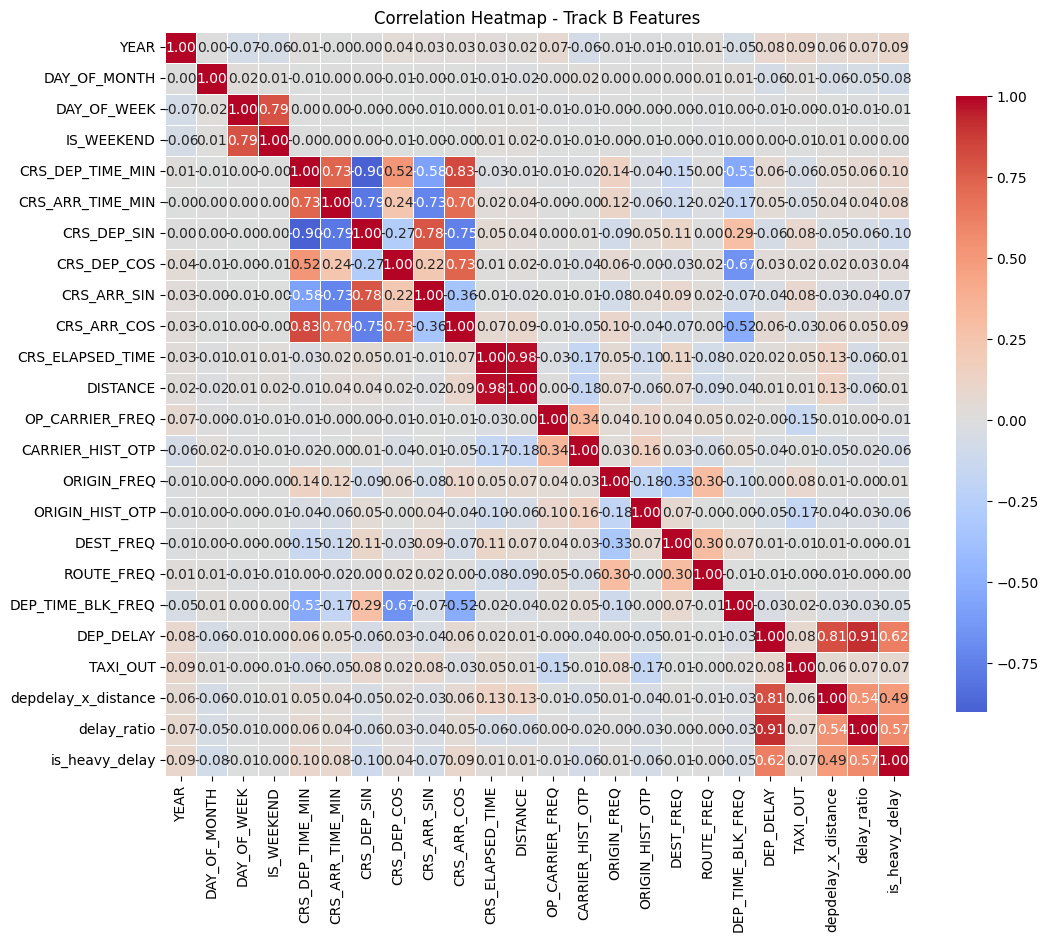

In [66]:
plt.figure(figsize=(12, 10))

corr =X_train.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,     
    fmt=".2f",          
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap - Track B Features")
plt.show()


In [67]:
corr_target = df_train.corr(numeric_only=True)["ARR_DEL15"].sort_values(ascending=False)
print(corr_target.head(28))

ARR_DEL15              1.000000
is_heavy_delay         0.723087
DEP_DELAY              0.498834
delay_ratio            0.467899
depdelay_x_distance    0.384769
TAXI_OUT               0.296815
YEAR                   0.116721
CRS_DEP_TIME_MIN       0.089406
CRS_ARR_COS            0.083369
CRS_ARR_TIME_MIN       0.077256
CRS_DEP_COS            0.035671
DISTANCE               0.019486
CRS_ELAPSED_TIME       0.018108
ORIGIN_FREQ            0.014452
IS_WEEKEND             0.012699
DAY_OF_WEEK            0.003808
ROUTE_FREQ            -0.002213
DEST_FREQ             -0.011938
OP_CARRIER_FREQ       -0.024169
DEP_TIME_BLK_FREQ     -0.036095
CRS_ARR_SIN           -0.069840
CARRIER_HIST_OTP      -0.070643
ORIGIN_HIST_OTP       -0.077811
DAY_OF_MONTH          -0.082888
CRS_DEP_SIN           -0.091525
Name: ARR_DEL15, dtype: float64


In [68]:
def evaluate_model(y_true, y_prob, threshold=0.5, name="Model"):
    y_pred = (y_prob >= threshold).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"\n{name}")
    print(f"Threshold: {threshold:.3f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("Confusion Matrix:\n", cm)

    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    }

In [69]:
def find_best_threshold(y_true, y_prob, metric="f1"):
    thresholds = np.arange(0.1, 0.9, 0.01)

    best_t = 0
    best_score = 0
    results = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        prec = precision_score(y_true, y_pred)
        rec  = recall_score(y_true, y_pred)
        f1   = f1_score(y_true, y_pred)

        score = {"f1": f1, "recall": rec, "precision": prec}[metric]

        results.append((t, prec, rec, f1))

        if score > best_score:
            best_score = score
            best_t = t

    results_df = pd.DataFrame(
        results, columns=["threshold", "precision", "recall", "f1"]
    )

    return best_t, results_df

In [70]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Best threshold LR: 0.7299999999999996

Logistic Regression
Threshold: 0.730
Accuracy : 0.9382
Precision: 0.8281
Recall   : 0.8471
F1-score : 0.8375
ROC-AUC  : 0.9616
Confusion Matrix:
 [[406879  17260]
 [ 15001  83129]]


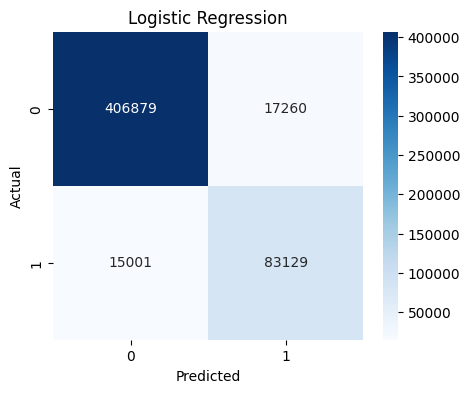

In [81]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  
        random_state=42
    ))
])
#train
lr_pipeline.fit(X_train, y_train)

# Validation tìm threshold
y_prob_val_lr = lr_pipeline.predict_proba(X_val)[:, 1]
best_t_lr, lr_table = find_best_threshold(y_val, y_prob_val_lr)

print("Best threshold LR:", best_t_lr)

# Test
y_prob_test_lr = lr_pipeline.predict_proba(X_test)[:, 1]

y_pred_lr = (y_prob_test_lr >= best_t_lr).astype(int)

results_lr = evaluate_model(
    y_test, y_prob_test_lr,
    threshold=best_t_lr,
    name="Logistic Regression"
)

plot_cm(y_test, y_pred_lr, "Logistic Regression")

[LightGBM] [Info] Number of positive: 300109, number of negative: 1230531
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042449 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3864
[LightGBM] [Info] Number of data points in the train set: 1530640, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196068 -> initscore=-1.411055
[LightGBM] [Info] Start training from score -1.411055
Best threshold LGB: 0.44999999999999984

LightGBM
Threshold: 0.450
Accuracy : 0.9458
Precision: 0.8739
Recall   : 0.8313
F1-score : 0.8521
ROC-AUC  : 0.9652
Confusion Matrix:
 [[412372  11767]
 [ 16550  81580]]


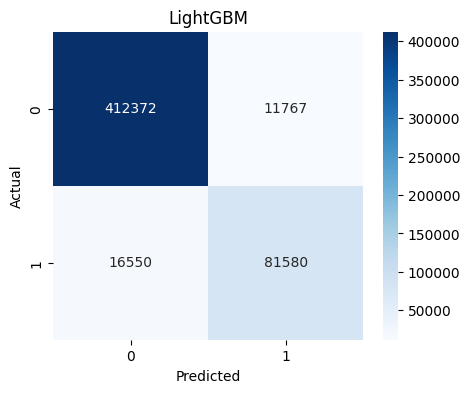

In [82]:
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.015,
    num_leaves=80,
    max_depth=-1,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Validation
y_prob_val_lgb = lgb_model.predict_proba(X_val)[:, 1]
best_t_lgb, lgb_table = find_best_threshold(y_val, y_prob_val_lgb)

print("Best threshold LGB:", best_t_lgb)

# Test
y_prob_test_lgb = lgb_model.predict_proba(X_test)[:, 1]

y_pred_lgb = (y_prob_test_lgb >= best_t_lgb).astype(int)

results_lgb = evaluate_model(
    y_test, y_prob_test_lgb,
    threshold=best_t_lgb,
    name="LightGBM"
)

plot_cm(y_test, y_pred_lgb, "LightGBM")

In [74]:
from tabulate import tabulate

results = [results_lr, results_lgb]
results_df = pd.DataFrame(results).round(4)

print("\nMODEL COMPARISON")
print(tabulate(results_df, headers='keys', tablefmt='fancy_grid', showindex=False))


MODEL COMPARISON
╒═════════════════════╤═════════════╤════════════╤═════════════╤══════════╤════════╤═══════════╕
│ Model               │   Threshold │   Accuracy │   Precision │   Recall │     F1 │   ROC-AUC │
╞═════════════════════╪═════════════╪════════════╪═════════════╪══════════╪════════╪═══════════╡
│ Logistic Regression │        0.73 │     0.9382 │      0.8281 │   0.8471 │ 0.8375 │    0.9616 │
├─────────────────────┼─────────────┼────────────┼─────────────┼──────────┼────────┼───────────┤
│ LightGBM            │        0.45 │     0.9458 │      0.8739 │   0.8313 │ 0.8521 │    0.9652 │
╘═════════════════════╧═════════════╧════════════╧═════════════╧══════════╧════════╧═══════════╛


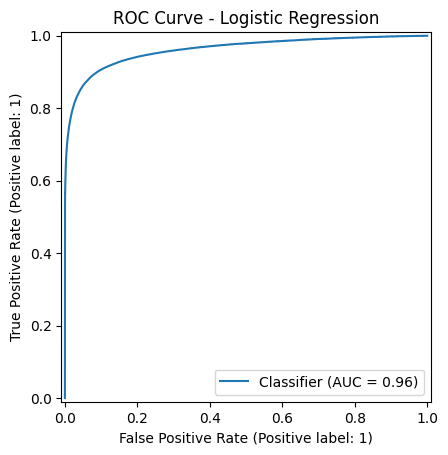

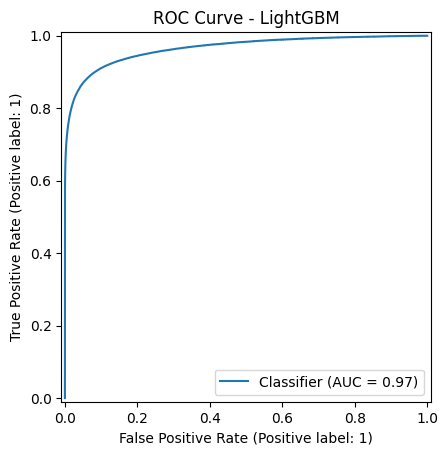

In [75]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob_test_lr)
plt.title("ROC Curve - Logistic Regression")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_test_lgb)
plt.title("ROC Curve - LightGBM")
plt.show()

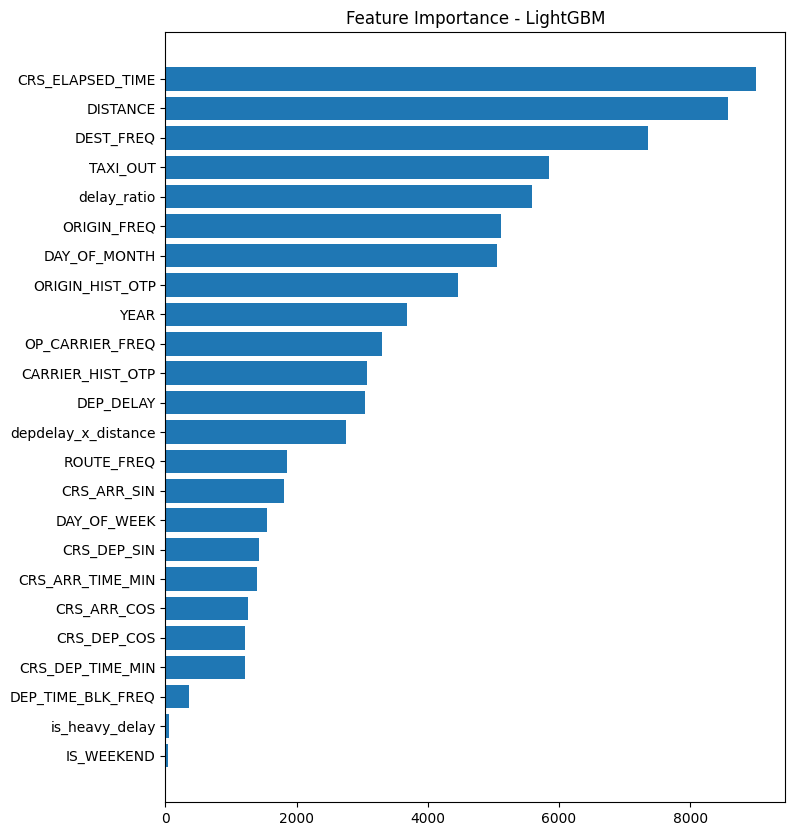

                feature  importance
10     CRS_ELAPSED_TIME        9002
11             DISTANCE        8576
16            DEST_FREQ        7357
20             TAXI_OUT        5843
22          delay_ratio        5588
14          ORIGIN_FREQ        5111
1          DAY_OF_MONTH        5059
15      ORIGIN_HIST_OTP        4465
0                  YEAR        3678
12      OP_CARRIER_FREQ        3300
13     CARRIER_HIST_OTP        3065
19            DEP_DELAY        3039
21  depdelay_x_distance        2752
17           ROUTE_FREQ        1858
8           CRS_ARR_SIN        1801
2           DAY_OF_WEEK        1548
6           CRS_DEP_SIN        1427
5      CRS_ARR_TIME_MIN        1396
9           CRS_ARR_COS        1256
7           CRS_DEP_COS        1218
4      CRS_DEP_TIME_MIN        1210
18    DEP_TIME_BLK_FREQ         353
23       is_heavy_delay          56
3            IS_WEEKEND          42


In [78]:
importances = lgb_model.feature_importances_
features = X_train_full.columns

indices = np.argsort(importances)

plt.figure(figsize=(8, 10))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Feature Importance - LightGBM")
plt.show()

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(25))

In [77]:
print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Test distribution:
ARR_DEL15
0    0.812108
1    0.187892
Name: proportion, dtype: Float64
